In [1]:
#Import Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Load Dataset

In [4]:
df = pd.read_csv("cleaned_dataset.csv")

print("Shape:", df.shape)
df.head()


Shape: (9997, 19)


,order_id,supplier_id,supplier_rating,supplier_lead_time,order_date,promised_delivery_date,actual_delivery_date,shipment_mode,shipping_distance_km,order_quantity,unit_price,total_order_value,weather_condition,region,holiday_period,previous_on_time_rate,carrier_name,delayed_reason_code,on_time_delivery
0,4,9832,3.9,7,2024-08-12,2024-08-19,2024-08-19,Air,839,71,365.79,25971.09,Rainy,India,No,85.2,FedEx,Operational,1
1,5,2126,3.2,8,2024-07-07,2024-07-15,2024-07-18,Sea,258,9,3052.84,27475.56,Cloudy,USA,No,77.1,BlueDart,Customs,0
2,6,4401,3.1,8,2024-05-05,2024-05-13,2024-05-14,Road,450,19,2569.78,4552.40,Cloudy,North,Yes,79.3,DHL,Traffic,0
3,7,8725,4.0,10,2024-10-14,2024-10-24,2024-10-25,Air,278,98,448.95,43997.10,Cloudy,South,Yes,87.2,Delhivery,Traffic,0
4,8,4079,4.2,7,2024-03-10,2024-03-17,2024-03-16,Sea,176,50,2833.97,141698.50,Rainy,East,No,92.2,FedEx,Operational,1


In [5]:
#Feature Engineering

In [6]:
# Convert date columns
date_cols = ['order_date', 'promised_delivery_date', 'actual_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Date-based features
df['order_weekday'] = df['order_date'].dt.day_name()
df['order_month'] = df['order_date'].dt.month

# Cost-to-weight / unit feature
df['cost_per_unit'] = df['total_order_value'] / df['order_quantity']


In [7]:
#Drop Leakage & ID Columns

In [8]:
drop_cols = [
    'order_id',
    'supplier_id',
    'order_date',
    'promised_delivery_date',
    'actual_delivery_date',
    'delivery_delay_days'  # safety
]

df = df.drop(columns=drop_cols, errors='ignore')


In [9]:
#Separate Features & Target

In [10]:
X = df.drop('on_time_delivery', axis=1)
y = df['on_time_delivery']

print(X.shape, y.shape)


(9997, 16) (9997,)


In [11]:
#Define Numerical & Categorical Columns

In [12]:
num_cols = [
    'supplier_rating',
    'supplier_lead_time',
    'shipping_distance_km',
    'order_quantity',
    'unit_price',
    'total_order_value',
    'previous_on_time_rate',
    'order_month',
    'cost_per_unit'
]

cat_cols = [
    'shipment_mode',
    'weather_condition',
    'region',
    'holiday_period',
    'carrier_name',
    'order_weekday'
]


In [13]:
#Build Preprocessing Pipeline

In [14]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


In [15]:
#Train–Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [17]:
#Apply Preprocessing

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)


Train shape: (7997, 31)
Test shape: (2000, 31)


In [19]:
#Feature Correlation Heatmap (Numerical)

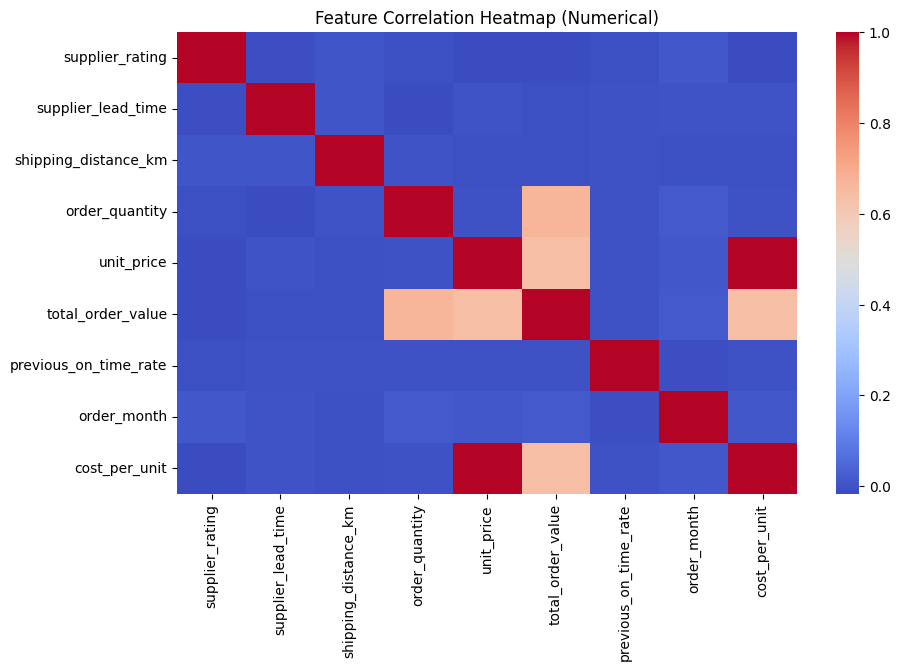

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[num_cols].corr(),
    cmap='coolwarm',
    annot=False
)
plt.title("Feature Correlation Heatmap (Numerical)")
plt.show()


In [21]:
#Save Preprocessor 

In [22]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")


['preprocessor.pkl']

In [23]:
# Sanity check (not final modeling)


In [24]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))


Original:
on_time_delivery
0    0.719616
1    0.280384
Name: proportion, dtype: float64

Train:
on_time_delivery
0    0.719645
1    0.280355
Name: proportion, dtype: float64

Test:
on_time_delivery
0    0.7195
1    0.2805
Name: proportion, dtype: float64


In [25]:
#Check feature matrix size makes sense

In [26]:
print(X.shape)
print(X_train_processed.shape)


(9997, 16)
(7997, 31)


In [27]:
#Preprocessing Correctness

In [28]:
#Confirm no NaNs after preprocessing

In [29]:
import numpy as np
np.isnan(X_train_processed).any()


np.False_

In [30]:
#Confirm numerical features are scaled

In [31]:
X_train_processed.mean(), X_train_processed.std()


(np.float64(0.14143206928404606), np.float64(0.6416787511732331))

In [32]:
#Model Behavior

In [33]:
#Baseline model sanity test

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train_processed, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train_processed))
test_acc = accuracy_score(y_test, model.predict(X_test_processed))

train_acc, test_acc


(0.7196448668250593, 0.7195)

In [35]:
#Metric Consistency

In [36]:
#Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, model.predict(X_test_processed)))
print(classification_report(y_test, model.predict(X_test_processed)))


[[1439    0]
 [ 561    0]]
              precision    recall  f1-score   support

           0       0.72      1.00      0.84      1439
           1       0.00      0.00      0.00       561

    accuracy                           0.72      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.52      0.72      0.60      2000



c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [38]:
#ROC-AUC

In [39]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test_processed)[:,1])


0.5203764745521684